In [ ]:
import qiskit
import numpy as np
import pandas as pd 
import scipy as sp
from scipy.stats import entropy
import matplotlib.pyplot as plt
from collections import Counter
import math 
import antropy as ant
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer


In [79]:
n = 10000

In [ ]:
### Generate n Pseudo random bits 

prng_bits = np.random.randint(0,2,n)
df_prng = pd.DataFrame({'prng_bit': prng_bits})
df_prng.to_csv(r'',index=False) ###path to pseudo random bits csv file


In [ ]:
### Generate n Quantum Random bits

simulator = Aer.get_backend('statevector_simulator')
qrng_bits = []

for _ in range(1000):
    qc = QuantumCircuit(1,1)
    qc.h(0)
    qc.measure(0,0)
    qc = transpile(qc,simulator)
    result = simulator.run(qc,shots=10).result()
    counts = result.get_counts()
    for bit,count in counts.items():
        qrng_bits.extend([int(bit)]*count)

###print(qrng_bits[:10])

df_qrng = pd.DataFrame({'qrng_bit': qrng_bits})
df_qrng.to_csv(r'',index=False) ###path to quantum random bits csv file
    

In [ ]:
df_combined = pd.concat([df_prng,df_qrng],axis=1)
df_combined.to_csv(r'',index=False) ###path to combined csv file with both prng and qrng bits

PRNG Entropy using Regular Entropy:  0.9999958450342934
QRNG Entropy using Regular Entropy:  0.9999219776456704
PRNG Entropy using Min Entropy:  0.9965416802275889
QRNG Entropy using Min Entropy:  0.9850734557618972
PRNG Entropy using Shannon Entropy:  0.9999958450342934
QRNG Entropy using Shannon Entropy:  0.9999219776456703
PRNG Entropy using Antropy:  0.7670979734542301
QRNG Entropy using Antropy:  0.2973011575674849


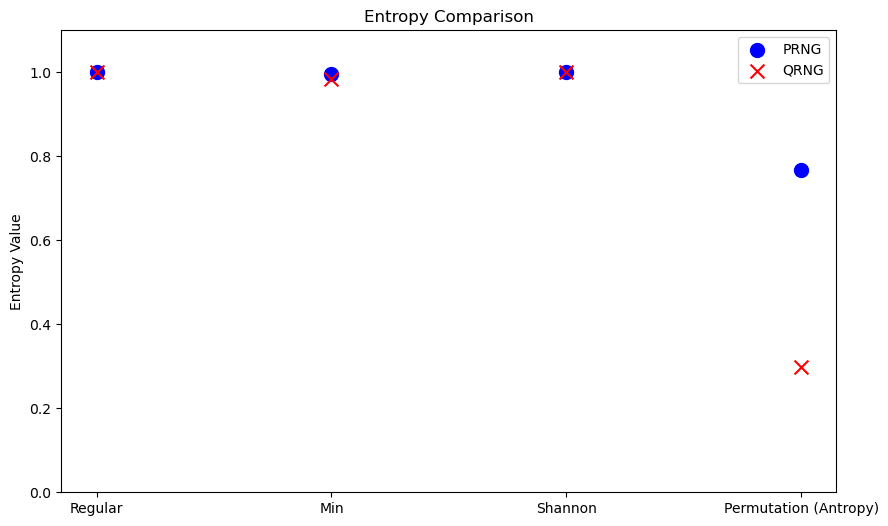

In [ ]:


def calc_entropy(bits):
    counts = [bits.count(0),bits.count(1)]
    return entropy(counts,base=2)

def min_entropy(bits):
    counts = Counter(bits)
    total = len(bits)
    probs = [count/total for count in counts.values()]
    return -math.log2(max(probs))

def shannon_entropy(bits):
    counts = Counter(bits)
    total = len(bits)
    return -sum((count/total)*math.log2(count/total) for count in counts.values())


prng_data = pd.read_csv(r'')['prng_bit'] ###path to random bits csv file
qrng_data = pd.read_csv(r'')['qrng_bit'] ###path to random bits csv file

print("PRNG Entropy using Regular Entropy: ", calc_entropy(prng_data.tolist()))
print("QRNG Entropy using Regular Entropy: ", calc_entropy(qrng_data.tolist()))

print("PRNG Entropy using Min Entropy: ", min_entropy(prng_data.tolist()))
print("QRNG Entropy using Min Entropy: ", min_entropy(qrng_data.tolist()))

print("PRNG Entropy using Shannon Entropy: ", shannon_entropy(prng_data.tolist()))
print("QRNG Entropy using Shannon Entropy: ", shannon_entropy(qrng_data.tolist()))

print("PRNG Entropy using Antropy: ", ant.perm_entropy(prng_data.tolist(), order=3, normalize=True))
print("QRNG Entropy using Antropy: ", ant.perm_entropy(qrng_data.tolist(), order=3, normalize=True))


# Calculate entropy values
entropy_measures = ['Regular', 'Min', 'Shannon', 'Permutation (Antropy)']

prng_entropies = [
    calc_entropy(prng_data.tolist()),
    min_entropy(prng_data.tolist()),
    shannon_entropy(prng_data.tolist()),
    ant.perm_entropy(prng_data.tolist(), order=3, normalize=True)
]

qrng_entropies = [
    calc_entropy(qrng_data.tolist()),
    min_entropy(qrng_data.tolist()),
    shannon_entropy(qrng_data.tolist()),
    ant.perm_entropy(qrng_data.tolist(), order=3, normalize=True)
]

x = np.arange(len(entropy_measures))

plt.figure(figsize=(10,6))

# Scatter points for PRNG and QRNG
plt.scatter(x, prng_entropies, color='blue', label='PRNG', s=100, marker='o')
plt.scatter(x, qrng_entropies, color='red', label='QRNG', s=100, marker='x')
plt.xticks(x, entropy_measures)
plt.ylabel('Entropy Value')
plt.title('Entropy Comparison')
plt.legend()
plt.ylim(0, max(max(prng_entropies), max(qrng_entropies)) + 0.1)
plt.show()


